In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('kidney_disease.csv')
df.head()

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 26 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              400 non-null    int64  
 1   age             391 non-null    float64
 2   bp              388 non-null    float64
 3   sg              353 non-null    float64
 4   al              354 non-null    float64
 5   su              351 non-null    float64
 6   rbc             248 non-null    object 
 7   pc              335 non-null    object 
 8   pcc             396 non-null    object 
 9   ba              396 non-null    object 
 10  bgr             356 non-null    float64
 11  bu              381 non-null    float64
 12  sc              383 non-null    float64
 13  sod             313 non-null    float64
 14  pot             312 non-null    float64
 15  hemo            348 non-null    float64
 16  pcv             330 non-null    object 
 17  wc              295 non-null    obj

In [4]:
df.drop('id', axis=1, inplace=True)

In [5]:
df.columns = ['age', 'blood_pressure', 'specific_gravity', 'albumin', 'sugar', 'red_blood_cells', 'pus_cell',
              'pus_cell_clumps', 'bacteria', 'blood_glucose_random', 'blood_urea', 'serum_creatinine', 'sodium',
              'potassium', 'haemoglobin', 'packed_cell_volume', 'white_blood_cell_count', 'red_blood_cell_count',
              'hypertension', 'diabetes_mellitus', 'coronary_artery_disease', 'appetite', 'peda_edema',
              'aanemia', 'class']

In [6]:
df['packed_cell_volume'] = pd.to_numeric(df['packed_cell_volume'], errors='coerce')
df['white_blood_cell_count'] = pd.to_numeric(df['white_blood_cell_count'], errors='coerce')
df['red_blood_cell_count'] = pd.to_numeric(df['red_blood_cell_count'], errors='coerce')

In [7]:
df

,age,blood_pressure,specific_gravity,albumin,sugar,red_blood_cells,pus_cell,pus_cell_clumps,bacteria,blood_glucose_random,...,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,hypertension,diabetes_mellitus,coronary_artery_disease,appetite,peda_edema,aanemia,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,55.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,140.0,...,47.0,6700.0,4.9,no,no,no,good,no,no,notckd
396,42.0,70.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,75.0,...,54.0,7800.0,6.2,no,no,no,good,no,no,notckd
397,12.0,80.0,1.020,0.0,0.0,normal,normal,notpresent,notpresent,100.0,...,49.0,6600.0,5.4,no,no,no,good,no,no,notckd
398,17.0,60.0,1.025,0.0,0.0,normal,normal,notpresent,notpresent,114.0,...,51.0,7200.0,5.9,no,no,no,good,no,no,notckd


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      391 non-null    float64
 1   blood_pressure           388 non-null    float64
 2   specific_gravity         353 non-null    float64
 3   albumin                  354 non-null    float64
 4   sugar                    351 non-null    float64
 5   red_blood_cells          248 non-null    object 
 6   pus_cell                 335 non-null    object 
 7   pus_cell_clumps          396 non-null    object 
 8   bacteria                 396 non-null    object 
 9   blood_glucose_random     356 non-null    float64
 10  blood_urea               381 non-null    float64
 11  serum_creatinine         383 non-null    float64
 12  sodium                   313 non-null    float64
 13  potassium                312 non-null    float64
 14  haemoglobin              3

In [9]:
df.isnull().sum()

age                          9
blood_pressure              12
specific_gravity            47
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random        44
blood_urea                  19
serum_creatinine            17
sodium                      87
potassium                   88
haemoglobin                 52
packed_cell_volume          71
white_blood_cell_count     106
red_blood_cell_count       131
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
class                        0
dtype: int64

<h1> Что делать с фичами у которых такое большое количество пропущенных значений?<h1>

In [10]:
cat_cols = [col for col in df.columns if df[col].dtype == 'object']
num_cols = [col for col in df.columns if df[col].dtype != 'object']

In [11]:
cat_cols

['red_blood_cells',
 'pus_cell',
 'pus_cell_clumps',
 'bacteria',
 'hypertension',
 'diabetes_mellitus',
 'coronary_artery_disease',
 'appetite',
 'peda_edema',
 'aanemia',
 'class']

In [12]:
num_cols

['age',
 'blood_pressure',
 'specific_gravity',
 'albumin',
 'sugar',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

<h1> Замена всех неправильно заполенных значений <h1>

In [13]:
for col in cat_cols:
    print(f'In col {col} values are: \n{df[col].value_counts()}' )

In col red_blood_cells values are: 
red_blood_cells
normal      201
abnormal     47
Name: count, dtype: int64
In col pus_cell values are: 
pus_cell
normal      259
abnormal     76
Name: count, dtype: int64
In col pus_cell_clumps values are: 
pus_cell_clumps
notpresent    354
present        42
Name: count, dtype: int64
In col bacteria values are: 
bacteria
notpresent    374
present        22
Name: count, dtype: int64
In col hypertension values are: 
hypertension
no     251
yes    147
Name: count, dtype: int64
In col diabetes_mellitus values are: 
diabetes_mellitus
no       258
yes      134
\tno       3
\tyes      2
 yes       1
Name: count, dtype: int64
In col coronary_artery_disease values are: 
coronary_artery_disease
no      362
yes      34
\tno      2
Name: count, dtype: int64
In col appetite values are: 
appetite
good    317
poor     82
Name: count, dtype: int64
In col peda_edema values are: 
peda_edema
no     323
yes     76
Name: count, dtype: int64
In col aanemia values are: 
aan

In [14]:
df['diabetes_mellitus'].replace(to_replace = {'\tno':'no', '\tyes': 'yes', ' yes':'yes'}, inplace=True)
df['coronary_artery_disease'] = df['coronary_artery_disease'].replace(to_replace = '\tno', value = 'no')
df['class'] = df['class'].replace(to_replace={'ckd\t':'ckd', 'notckd': 'not ckd'})

In [15]:
df['class'] = df['class'].map({'ckd':0, 'not ckd': 1})
df['class'] = pd.to_numeric(df['class'], errors = 'coerce')

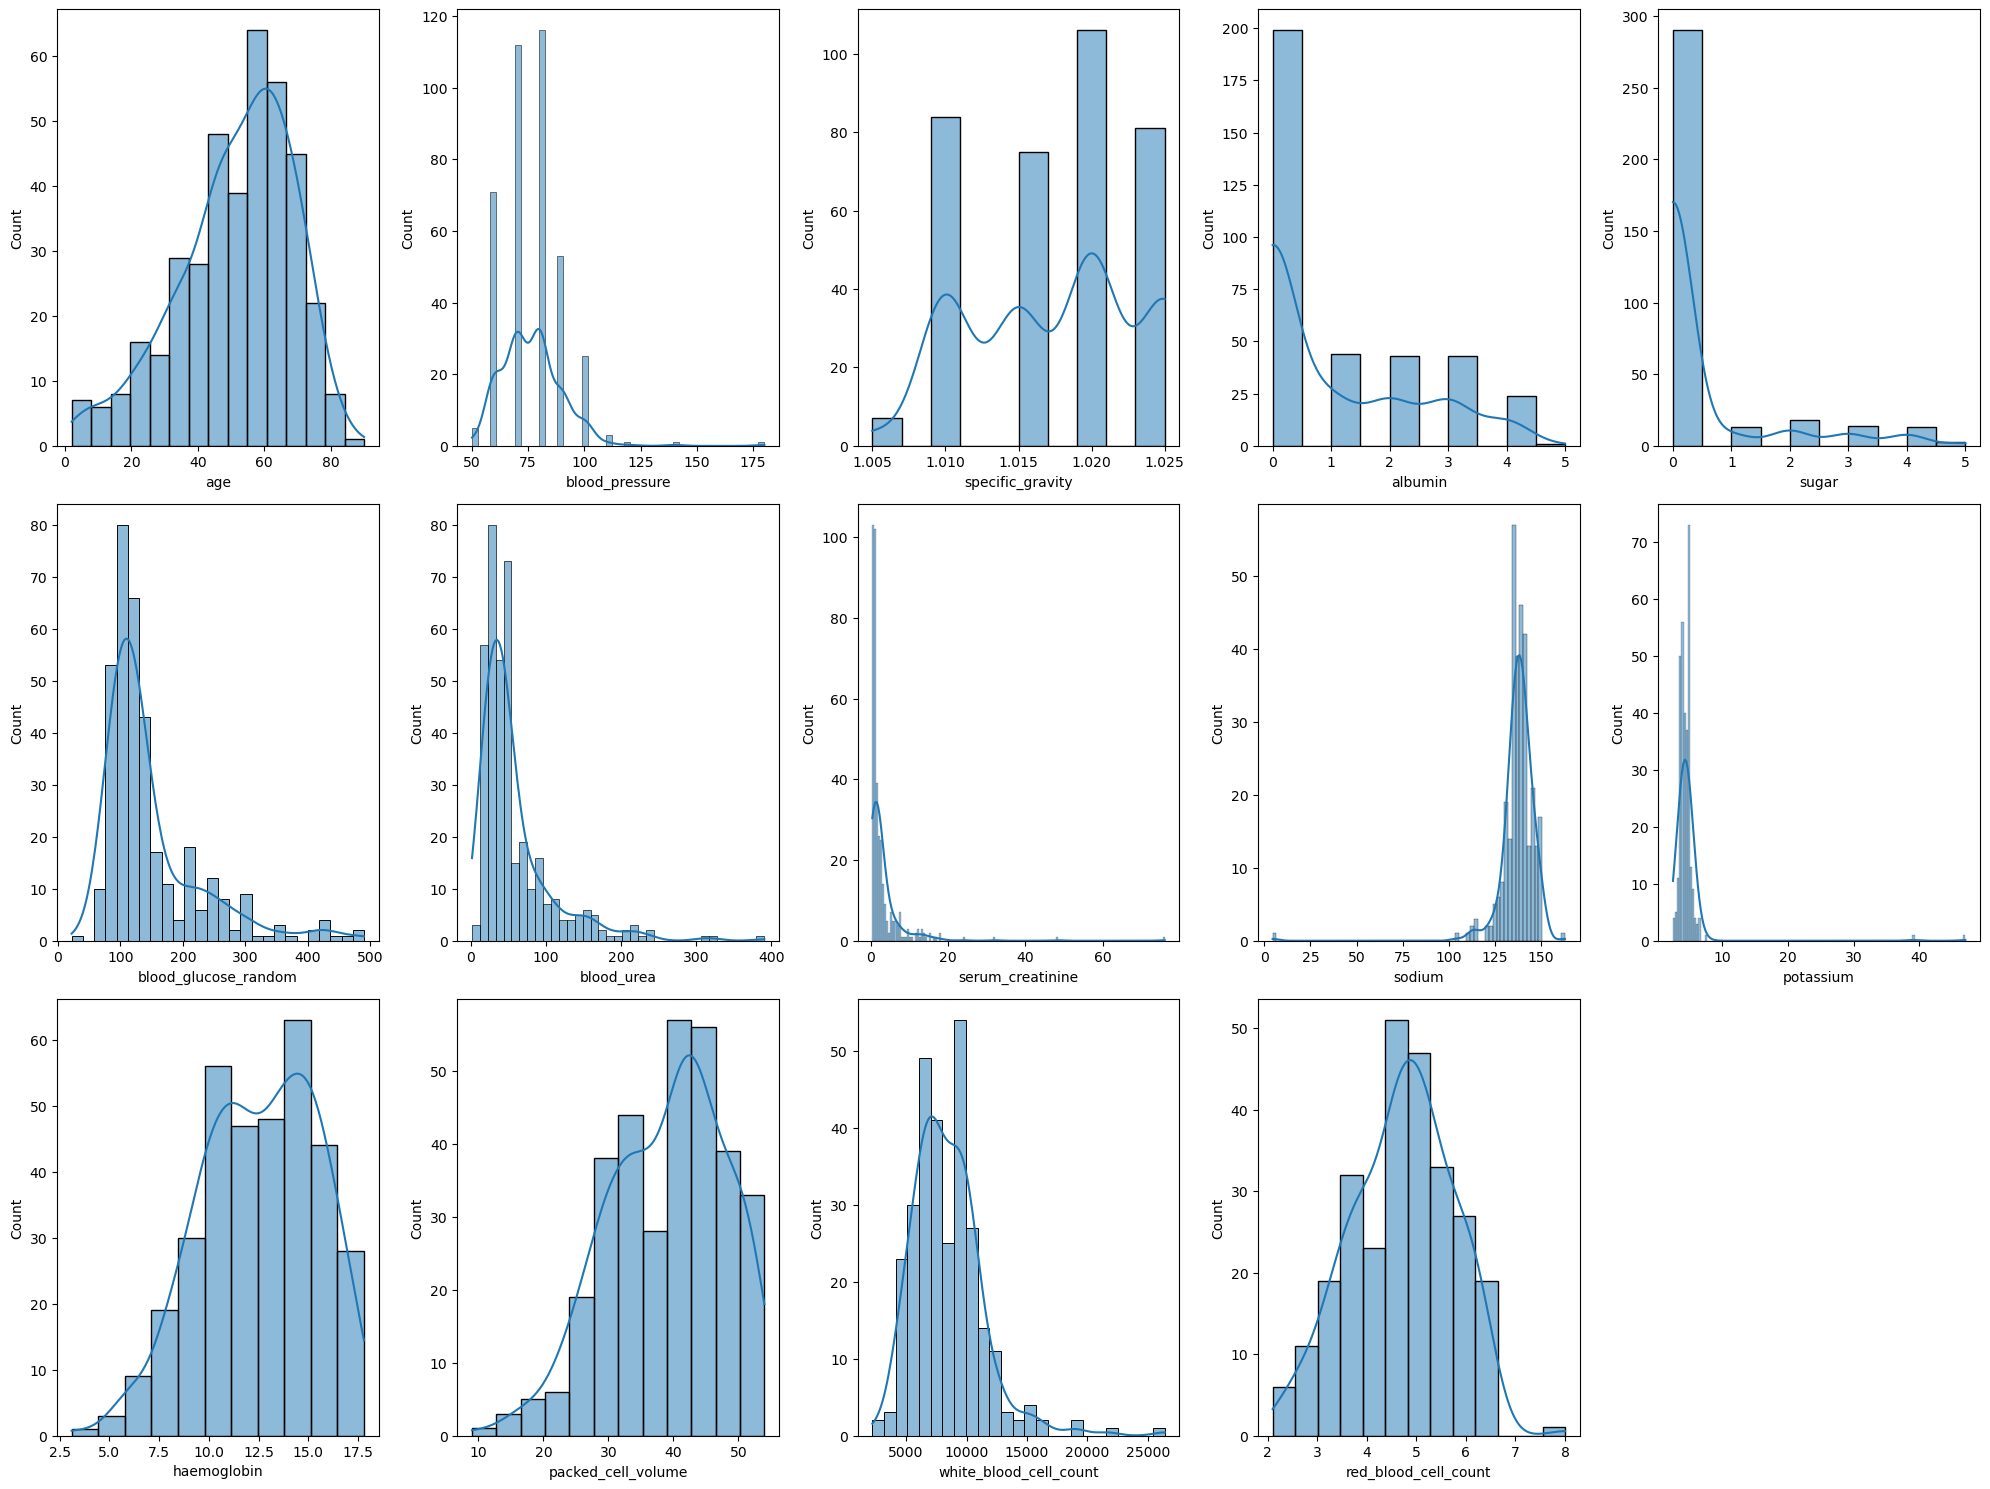

In [16]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in num_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        skewness = df[column].skew()
        sns.histplot(df[column], kde=True, label=f"Skew = {skewness:.3f}")
        plt.xlabel(column)
        
    plotnumber += 1

plt.tight_layout()
plt.show()

In [20]:
df.describe()

,age,blood_pressure,specific_gravity,albumin,sugar,blood_glucose_random,blood_urea,serum_creatinine,sodium,potassium,haemoglobin,packed_cell_volume,white_blood_cell_count,red_blood_cell_count,class
count,391.000000,388.000000,353.000000,354.000000,351.000000,356.000000,381.000000,383.000000,313.000000,312.000000,348.000000,329.000000,294.000000,269.000000,400.000000
mean,51.483376,76.469072,1.017408,1.016949,0.450142,148.036517,57.425722,3.072454,137.528754,4.627244,12.526437,38.884498,8406.122449,4.707435,0.375000
std,17.169714,13.683637,0.005717,1.352679,1.099191,79.281714,50.503006,5.741126,10.408752,3.193904,2.912587,8.990105,2944.474190,1.025323,0.484729
min,2.000000,50.000000,1.005000,0.000000,0.000000,22.000000,1.500000,0.400000,4.500000,2.500000,3.100000,9.000000,2200.000000,2.100000,0.000000
25%,42.000000,70.000000,1.010000,0.000000,0.000000,99.000000,27.000000,0.900000,135.000000,3.800000,10.300000,32.000000,6500.000000,3.900000,0.000000
50%,55.000000,80.000000,1.020000,0.000000,0.000000,121.000000,42.000000,1.300000,138.000000,4.400000,12.650000,40.000000,8000.000000,4.800000,0.000000
75%,64.500000,80.000000,1.020000,2.000000,0.000000,163.000000,66.000000,2.800000,142.000000,4.900000,15.000000,45.000000,9800.000000,5.400000,1.000000
max,90.000000,180.000000,1.025000,5.000000,5.000000,490.000000,391.000000,76.000000,163.000000,47.000000,17.800000,54.000000,26400.000000,8.000000,1.000000


<h1> Фичи "Albumin" и "Sugar" представлены в числовом формате, но по сути являются категориальными.<h1>

<h1> Для остальных фичей с вещественными значениями,у которых есть пропуски в данных, заполним эти пропуски. Лучше пропуски заполнить средним значением, а не медианным, так как распределение значений внутри этих фичей не похоже на нормальное, следовательно заполнение медианным значением приведет к большому перекосу.<h1>  
    (Вопрос: правильно ли это и в каких ситуациях лучше заполнять пропуски иначе?)

In [26]:
num_cols_without_categorical = num_cols
num_cols_without_categorical.remove('albumin')
num_cols_without_categorical.remove('sugar')

In [28]:
num_cols_without_categorical

['age',
 'blood_pressure',
 'specific_gravity',
 'blood_glucose_random',
 'blood_urea',
 'serum_creatinine',
 'sodium',
 'potassium',
 'haemoglobin',
 'packed_cell_volume',
 'white_blood_cell_count',
 'red_blood_cell_count']

In [29]:
for col in num_cols_without_categorical:
    df[col].fillna(df[col].mean(), inplace=True)

In [31]:
df.isnull().sum()

age                          0
blood_pressure               0
specific_gravity             0
albumin                     46
sugar                       49
red_blood_cells            152
pus_cell                    65
pus_cell_clumps              4
bacteria                     4
blood_glucose_random         0
blood_urea                   0
serum_creatinine             0
sodium                       0
potassium                    0
haemoglobin                  0
packed_cell_volume           0
white_blood_cell_count       0
red_blood_cell_count         0
hypertension                 2
diabetes_mellitus            2
coronary_artery_disease      2
appetite                     1
peda_edema                   1
aanemia                      1
class                        0
dtype: int64

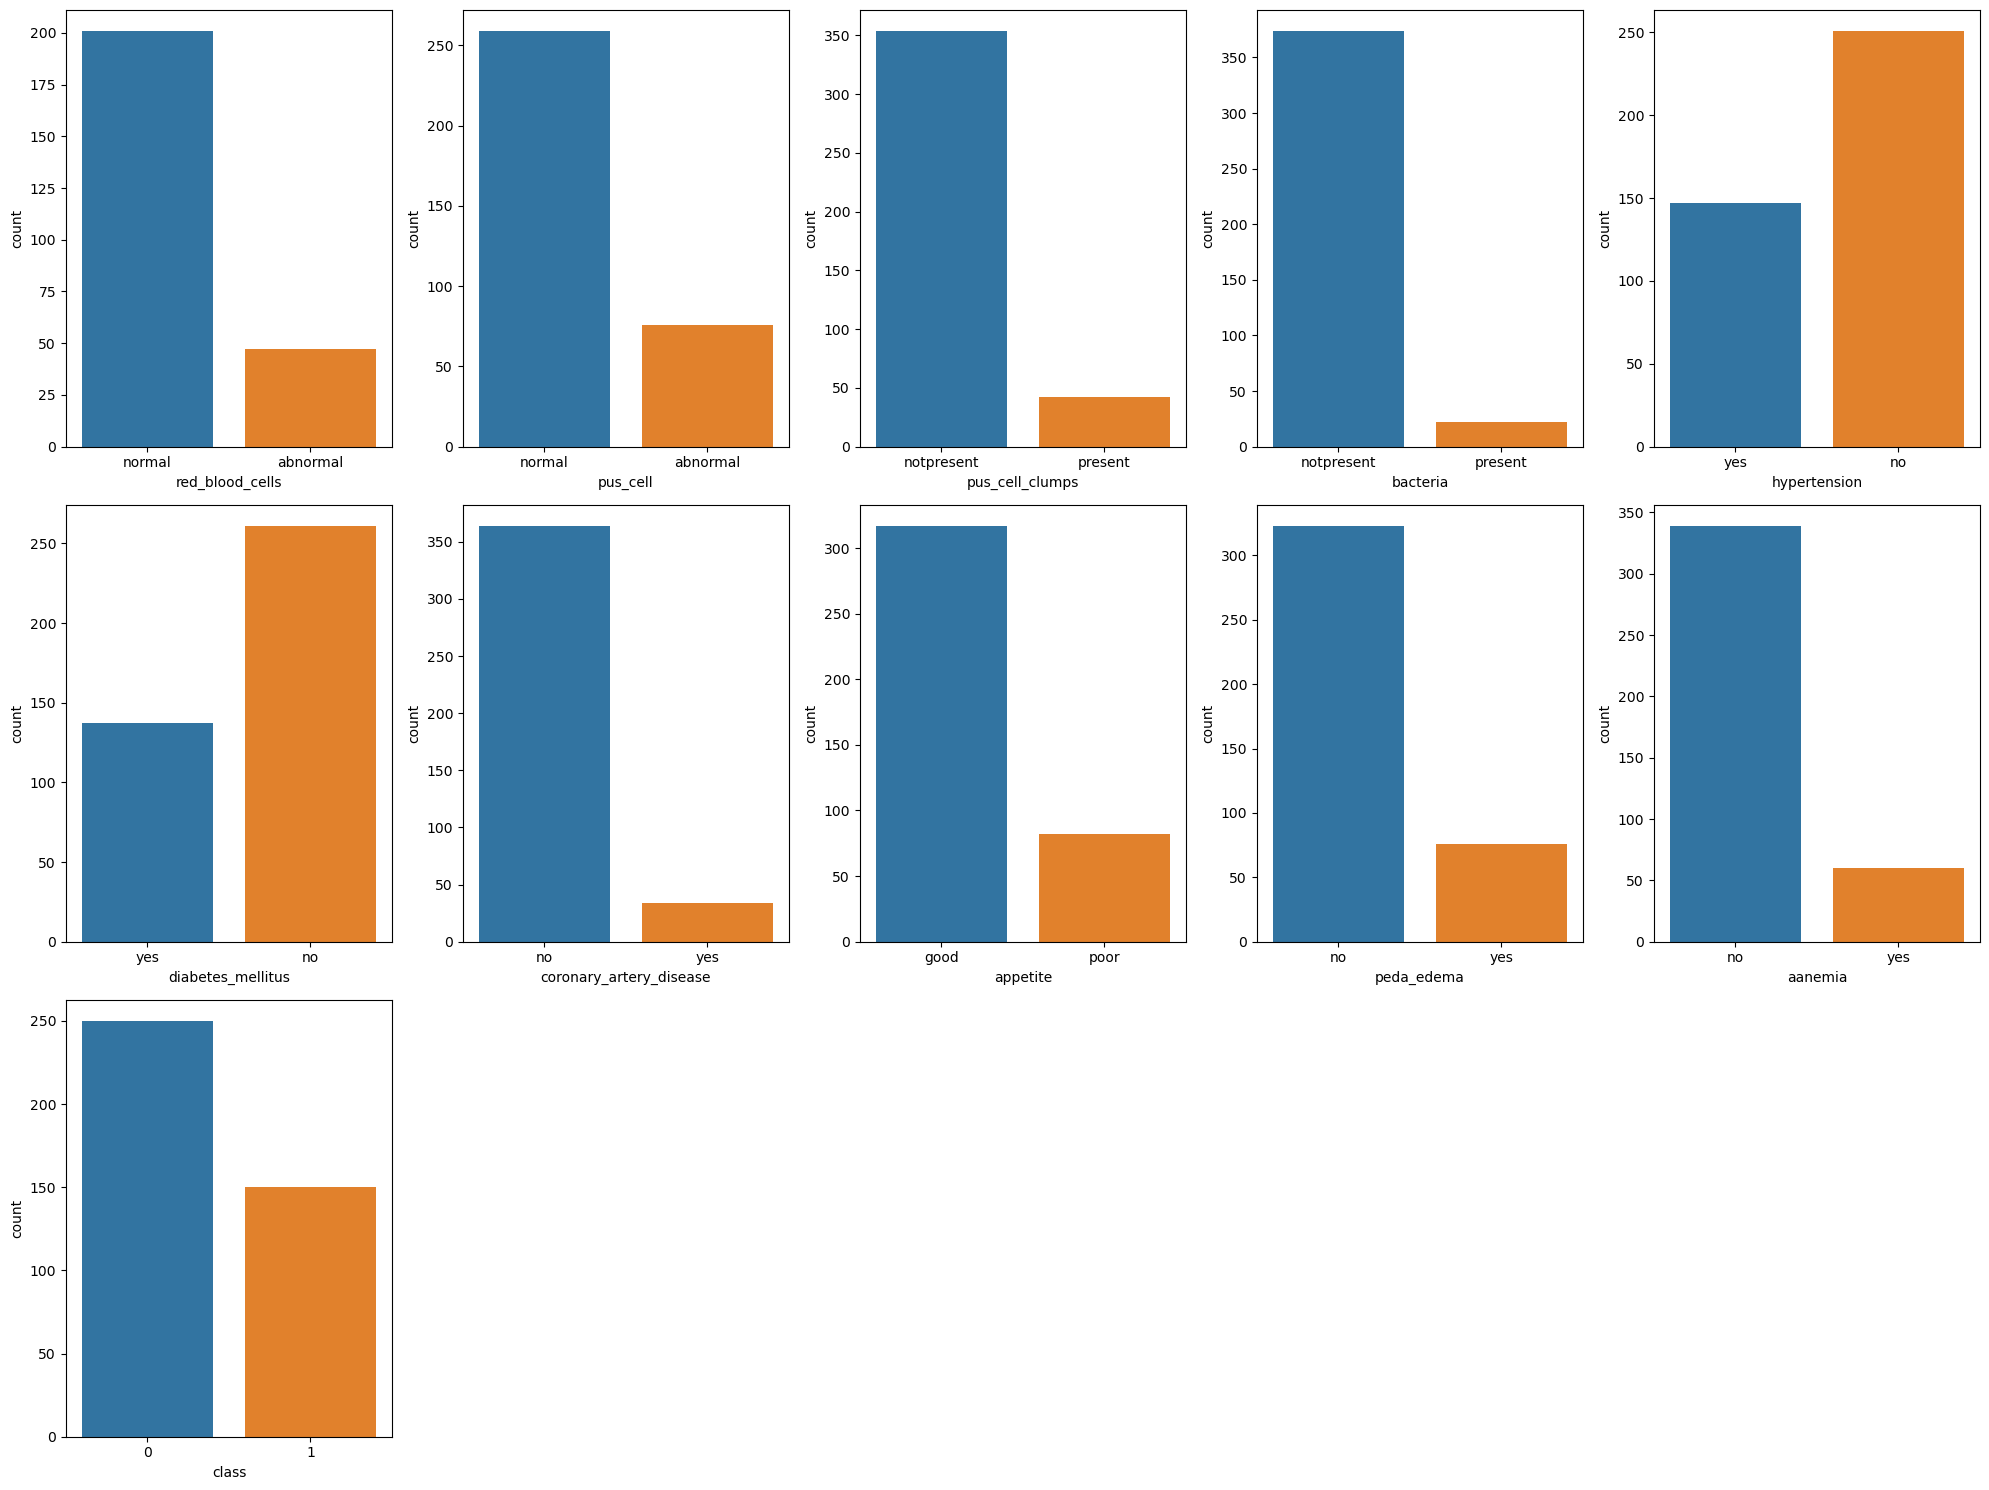

In [37]:
plt.figure(figsize = (20, 15))
plotnumber = 1

for column in cat_cols:
    if plotnumber <= 14:
        ax = plt.subplot(3, 5, plotnumber)
        sns.countplot(data=df, x=column)
        plt.xlabel(column)
        
    plotnumber += 1

plt.tight_layout()
plt.show()

<h1> В фичах 'red_blood_cells' и 'pus_cell' много пропущенных значений, при этом отношение normal к abnormal примерно 5 к 1. Заменим пропуски в данных рандомными значениями normal/abnormal в том же соотнешении, чтоы избежать перекоса данных. В остальных фичах пропущенных значений мало, поэтом в пропусках поставим преобладающую категорию<h1>

In [43]:
rbc_num_missing = df['red_blood_cells'].isna().sum()

num_normal = int(rbc_num_missing * 4 / 5)  # 4 частей из 5
num_abnormal = rbc_num_missing - num_normal  # оставшаяся 1 часть

replacement_values = ['normal'] * num_normal + ['abnormal'] * num_abnormal
np.random.shuffle(replacement_values)

df.loc[df['red_blood_cells'].isna(), 'red_blood_cells'] = replacement_values

In [45]:
pus_num_missing = df['pus_cell'].isna().sum()

num_normal = int(pus_num_missing * 4 / 5)  # 4 частей из 5
num_abnormal = pus_num_missing - num_normal  # оставшаяся 1 часть

replacement_values = ['normal'] * num_normal + ['abnormal'] * num_abnormal
np.random.shuffle(replacement_values)

df.loc[df['pus_cell'].isna(), 'pus_cell'] = replacement_values

In [47]:
df.loc[df['pus_cell_clumps'].isna(), 'pus_cell_clumps'] = 'notpresent'
df.loc[df['bacteria'].isna(), 'bacteria'] = 'notpresent'
df.loc[df['hypertension'].isna(), 'hypertension'] = 'no'
df.loc[df['diabetes_mellitus'].isna(), 'diabetes_mellitus'] = 'no'
df.loc[df['coronary_artery_disease'].isna(), 'coronary_artery_disease'] = 'no'
df.loc[df['appetite'].isna(), 'appetite'] = 'good'
df.loc[df['peda_edema'].isna(), 'peda_edema'] = 'no'
df.loc[df['aanemia'].isna(), 'aanemia'] = 'no'

In [48]:
df.isnull().sum()

age                         0
blood_pressure              0
specific_gravity            0
albumin                    46
sugar                      49
red_blood_cells             0
pus_cell                    0
pus_cell_clumps             0
bacteria                    0
blood_glucose_random        0
blood_urea                  0
serum_creatinine            0
sodium                      0
potassium                   0
haemoglobin                 0
packed_cell_volume          0
white_blood_cell_count      0
red_blood_cell_count        0
hypertension                0
diabetes_mellitus           0
coronary_artery_disease     0
appetite                    0
peda_edema                  0
aanemia                     0
class                       0
dtype: int64

<h1> В оставшихся фичах 'albumin' и 'sugar' не так много пропущенных значений и сами значения принимают вид от 0 до 5, поэтому заполним эти фичи случайными значениями в этом диапозоне.<h1>

In [52]:
alb_num_missing = df['albumin'].isna().sum()

replacement_values = np.random.randint(0, 6, size=alb_num_missing)
df.loc[df['albumin'].isna(), 'albumin'] = replacement_values

In [53]:
sug_num_missing = df['sugar'].isna().sum()

replacement_values = np.random.randint(0, 6, size=sug_num_missing)
df.loc[df['sugar'].isna(), 'sugar'] = replacement_values

In [54]:
df.isnull().sum()

age                        0
blood_pressure             0
specific_gravity           0
albumin                    0
sugar                      0
red_blood_cells            0
pus_cell                   0
pus_cell_clumps            0
bacteria                   0
blood_glucose_random       0
blood_urea                 0
serum_creatinine           0
sodium                     0
potassium                  0
haemoglobin                0
packed_cell_volume         0
white_blood_cell_count     0
red_blood_cell_count       0
hypertension               0
diabetes_mellitus          0
coronary_artery_disease    0
appetite                   0
peda_edema                 0
aanemia                    0
class                      0
dtype: int64

<h1> пропущенных значений больше нет, перекодируем категориальные данные <h1>

In [56]:
for col in cat_cols:
    print(f"{col} has {df[col].nunique()}")

red_blood_cells has 2
pus_cell has 2
pus_cell_clumps has 2
bacteria has 2
hypertension has 2
diabetes_mellitus has 2
coronary_artery_disease has 2
appetite has 2
peda_edema has 2
aanemia has 2
class has 2


In [57]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

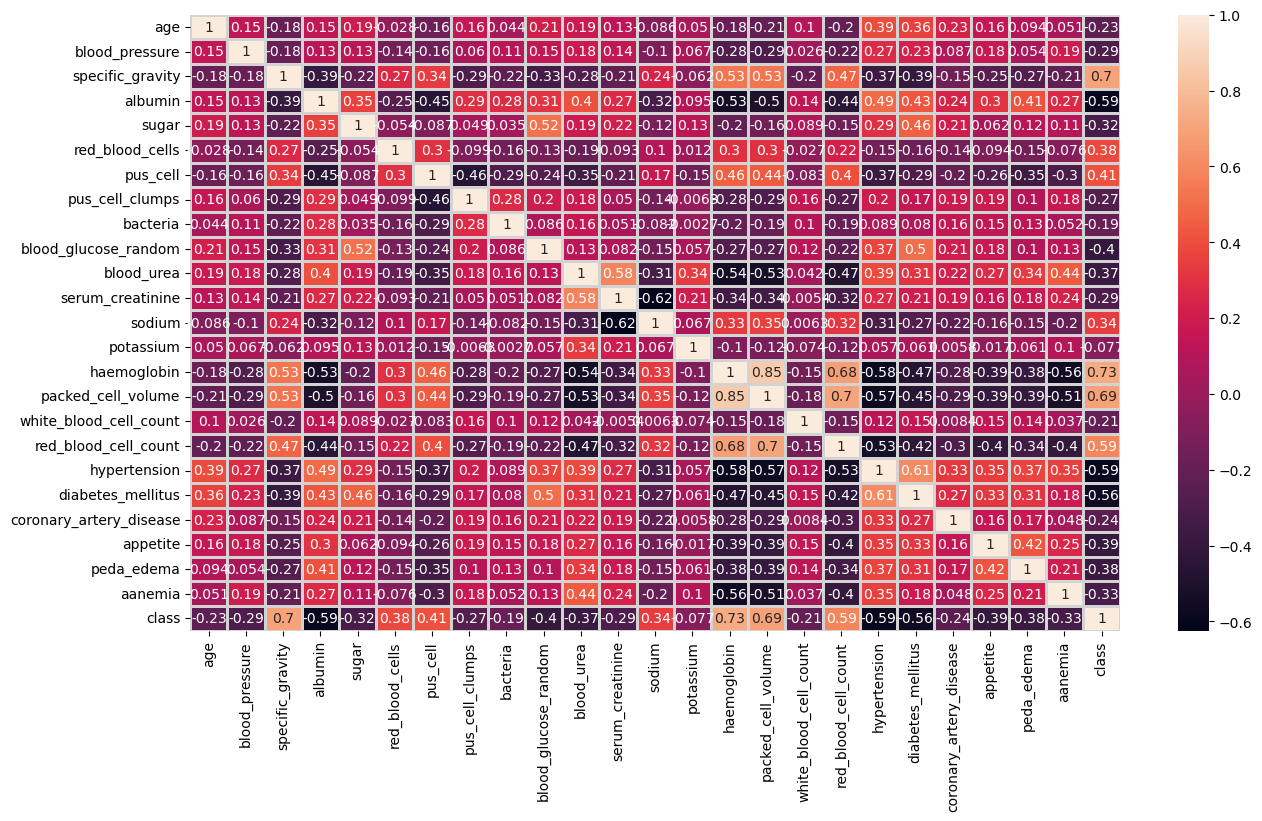

In [59]:
plt.figure(figsize = (15,8))
sns.heatmap(df.corr(), annot=True, linewidth=2, linecolor = 'lightgray')
plt.show()

<h1> Высокая положительная корреляция с таргетом: specific_gravity, haemoglobin и packed_cell_volume. У последних двух фичей большая корреляция между собой, поэтому можно оставить первую <h1>

<h1>Высокая отрицательная корреляция с таргетом: albunim, hypertension <h1>

<h1> Классификация (без уменьшения размерности)<h1>

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [76]:
X = df.iloc[:,:-1]
y = df.iloc[:, -1]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [77]:
def accuracy(X_train, X_test, y_train, y_test):
    reg = LogisticRegression()
    reg.fit(X_train, y_train)
    y_reg = reg.predict(X_test)
    
    svc = SVC()
    svc.fit(X_train, y_train)
    y_svc = svc.predict(X_test)
    
    dtc = DecisionTreeClassifier()
    dtc.fit(X_train, y_train)
    y_dtc = dtc.predict(X_test)
    
    rfc = RandomForestClassifier()
    rfc.fit(X_train, y_train)
    y_rfc = rfc.predict(X_test)
    
    gbc = GradientBoostingClassifier()
    gbc.fit(X_train, y_train)
    y_gbc = gbc.predict(X_test)
    
    cat = CatBoostClassifier()
    cat.fit(X_train, y_train)
    y_cat = cat.predict(X_test)
    
    return accuracy_score(y_test, y_reg), accuracy_score(y_test, y_svc), accuracy_score(y_test, y_dtc), accuracy_score(y_test, y_rfc), accuracy_score(y_test, y_gbc), accuracy_score(y_test, y_cat)

In [78]:
def precision(X_train, X_test, y_train, y_test):
    reg = LogisticRegression()
    reg.fit(X_train, y_train)
    y_reg = reg.predict(X_test)
    
    svc = SVC()
    svc.fit(X_train, y_train)
    y_svc = svc.predict(X_test)
    
    dtc = DecisionTreeClassifier()
    dtc.fit(X_train, y_train)
    y_dtc = dtc.predict(X_test)
    
    rfc = RandomForestClassifier()
    rfc.fit(X_train, y_train)
    y_rfc = rfc.predict(X_test)
    
    gbc = GradientBoostingClassifier()
    gbc.fit(X_train, y_train)
    y_gbc = gbc.predict(X_test)
    
    cat = CatBoostClassifier()
    cat.fit(X_train, y_train)
    y_cat = cat.predict(X_test)
    
    
    return precision_score(y_test, y_reg), precision_score(y_test, y_svc), precision_score(y_test, y_dtc), precision_score(y_test, y_rfc), precision_score(y_test, y_gbc), precision_score(y_test, y_cat)

In [79]:
def recall(X_train, X_test, y_train, y_test):
    reg = LogisticRegression()
    reg.fit(X_train, y_train)
    y_reg = reg.predict(X_test)
    
    svc = SVC()
    svc.fit(X_train, y_train)
    y_svc = svc.predict(X_test)
    
    dtc = DecisionTreeClassifier()
    dtc.fit(X_train, y_train)
    y_dtc = dtc.predict(X_test)
    
    rfc = RandomForestClassifier()
    rfc.fit(X_train, y_train)
    y_rfc = rfc.predict(X_test)
    
    gbc = GradientBoostingClassifier()
    gbc.fit(X_train, y_train)
    y_gbc = gbc.predict(X_test)
    
    cat = CatBoostClassifier()
    cat.fit(X_train, y_train)
    y_cat = cat.predict(X_test)
    
    
    return recall_score(y_test, y_reg), recall_score(y_test, y_svc), recall_score(y_test, y_dtc), recall_score(y_test, y_rfc), recall_score(y_test, y_gbc), recall_score(y_test, y_cat)

In [80]:
def f_1(X_train, X_test, y_train, y_test):
    reg = LogisticRegression()
    reg.fit(X_train, y_train)
    y_reg = reg.predict(X_test)
    
    svc = SVC()
    svc.fit(X_train, y_train)
    y_svc = svc.predict(X_test)
    
    dtc = DecisionTreeClassifier()
    dtc.fit(X_train, y_train)
    y_dtc = dtc.predict(X_test)
    
    rfc = RandomForestClassifier()
    rfc.fit(X_train, y_train)
    y_rfc = rfc.predict(X_test)
    
    gbc = GradientBoostingClassifier()
    gbc.fit(X_train, y_train)
    y_gbc = gbc.predict(X_test)
    
    cat = CatBoostClassifier()
    cat.fit(X_train, y_train)
    y_cat = cat.predict(X_test)
    
    
    return f1_score(y_test, y_reg), f1_score(y_test, y_svc), f1_score(y_test, y_dtc), f1_score(y_test, y_rfc), f1_score(y_test, y_gbc), f1_score(y_test, y_cat)

In [81]:
metrics = pd.DataFrame(columns = ["Reg", "SVC", "DesiTree", "RandForest", "GradBoosting", "CatBoosting"],
                      index = ["Accuracy", "Precision", "Recall", "F1"])

metrics

,Reg,SVC,DesiTree,RandForest,GradBoosting,CatBoosting
Accuracy,NaN,NaN,NaN,NaN,NaN,NaN
Precision,NaN,NaN,NaN,NaN,NaN,NaN
Recall,NaN,NaN,NaN,NaN,NaN,NaN
F1,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
acc = [reg, svc, dtc, rfc, gbc, cat] = accuracy(X_train, X_test, y_train, y_test)
metrics.iloc[0, :] = acc
prec = [reg, svc, dtc, rfc, gbc, cat] = precision(X_train, X_test, y_train, y_test)
metrics.iloc[1, :] = prec
rec = [reg, svc, dtc, rfc, gbc, cat] = recall(X_train, X_test, y_train, y_test)
metrics.iloc[2, :] = rec
f_1 = [reg, svc, dtc, rfc, gbc, cat] = f_1(X_train, X_test, y_train, y_test)
metrics.iloc[3, :] = f_1

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Learning rate set to 0.006333
0:	learn: 0.6825760	total: 1.33ms	remaining: 1.33s
1:	learn: 0.6737554	total: 2.68ms	remaining: 1.34s
2:	learn: 0.6608199	total: 3.52ms	remaining: 1.17s
3:	learn: 0.6526961	total: 4.7ms	remaining: 1.17s
4:	learn: 0.6420056	total: 5.9ms	remaining: 1.17s
5:	learn: 0.6331003	total: 7.09ms	remaining: 1.17s
6:	learn: 0.6235591	total: 8.32ms	remaining: 1.18s
7:	learn: 0.6156601	total: 9.61ms	remaining: 1.19s
8:	learn: 0.6067651	total: 10.8ms	remaining: 1.19s
9:	learn: 0.5976009	total: 12.2ms	remaining: 1.21s
10:	learn: 0.5873349	total: 13.4ms	remaining: 1.2s
11:	learn: 0.5785024	total: 14.6ms	remaining: 1.2s
12:	learn: 0.5694408	total: 16.1ms	remaining: 1.22s
13:	learn: 0.5602509	total: 17.5ms	remaining: 1.23s
14:	learn: 0.5502727	total: 18.7ms	remaining: 1.23s
15:	learn: 0.5431683	total: 20ms	remaining: 1.23s
16:	learn: 0.5358461	total: 21.2ms	remaining: 1.23s
17:	learn: 0.5275033	total: 22.5ms	remaining: 1.23s
18:	learn: 0.5194459	total: 23.7ms	remaining: 1.23

165:	learn: 0.0967515	total: 198ms	remaining: 995ms
166:	learn: 0.0958760	total: 200ms	remaining: 995ms
167:	learn: 0.0952113	total: 201ms	remaining: 995ms
168:	learn: 0.0946554	total: 202ms	remaining: 994ms
169:	learn: 0.0937416	total: 203ms	remaining: 993ms
170:	learn: 0.0928851	total: 205ms	remaining: 992ms
171:	learn: 0.0920427	total: 206ms	remaining: 991ms
172:	learn: 0.0912102	total: 207ms	remaining: 990ms
173:	learn: 0.0905551	total: 208ms	remaining: 988ms
174:	learn: 0.0898982	total: 210ms	remaining: 988ms
175:	learn: 0.0893362	total: 211ms	remaining: 988ms
176:	learn: 0.0885931	total: 213ms	remaining: 989ms
177:	learn: 0.0878738	total: 214ms	remaining: 988ms
178:	learn: 0.0871328	total: 215ms	remaining: 987ms
179:	learn: 0.0864378	total: 217ms	remaining: 987ms
180:	learn: 0.0857007	total: 218ms	remaining: 986ms
181:	learn: 0.0852105	total: 219ms	remaining: 983ms
182:	learn: 0.0845499	total: 220ms	remaining: 983ms
183:	learn: 0.0839841	total: 221ms	remaining: 981ms
184:	learn: 

325:	learn: 0.0369133	total: 395ms	remaining: 817ms
326:	learn: 0.0367492	total: 397ms	remaining: 817ms
327:	learn: 0.0365882	total: 398ms	remaining: 815ms
328:	learn: 0.0364432	total: 399ms	remaining: 814ms
329:	learn: 0.0362950	total: 401ms	remaining: 814ms
330:	learn: 0.0361496	total: 402ms	remaining: 813ms
331:	learn: 0.0359523	total: 403ms	remaining: 812ms
332:	learn: 0.0357388	total: 405ms	remaining: 811ms
333:	learn: 0.0355575	total: 406ms	remaining: 810ms
334:	learn: 0.0354634	total: 408ms	remaining: 810ms
335:	learn: 0.0353244	total: 409ms	remaining: 809ms
336:	learn: 0.0352031	total: 410ms	remaining: 807ms
337:	learn: 0.0350815	total: 412ms	remaining: 806ms
338:	learn: 0.0349382	total: 413ms	remaining: 805ms
339:	learn: 0.0347842	total: 414ms	remaining: 804ms
340:	learn: 0.0346416	total: 415ms	remaining: 803ms
341:	learn: 0.0344085	total: 417ms	remaining: 801ms
342:	learn: 0.0342182	total: 418ms	remaining: 800ms
343:	learn: 0.0340448	total: 419ms	remaining: 799ms
344:	learn: 

621:	learn: 0.0139660	total: 778ms	remaining: 473ms
622:	learn: 0.0139428	total: 779ms	remaining: 472ms
623:	learn: 0.0139164	total: 780ms	remaining: 470ms
624:	learn: 0.0138772	total: 782ms	remaining: 469ms
625:	learn: 0.0138384	total: 783ms	remaining: 468ms
626:	learn: 0.0137971	total: 784ms	remaining: 467ms
627:	learn: 0.0137583	total: 785ms	remaining: 465ms
628:	learn: 0.0137289	total: 788ms	remaining: 465ms
629:	learn: 0.0136925	total: 791ms	remaining: 465ms
630:	learn: 0.0136532	total: 792ms	remaining: 463ms
631:	learn: 0.0136309	total: 794ms	remaining: 462ms
632:	learn: 0.0135943	total: 795ms	remaining: 461ms
633:	learn: 0.0135545	total: 797ms	remaining: 460ms
634:	learn: 0.0135189	total: 798ms	remaining: 459ms
635:	learn: 0.0134818	total: 800ms	remaining: 458ms
636:	learn: 0.0134552	total: 802ms	remaining: 457ms
637:	learn: 0.0134158	total: 803ms	remaining: 456ms
638:	learn: 0.0133815	total: 804ms	remaining: 454ms
639:	learn: 0.0133385	total: 806ms	remaining: 453ms
640:	learn: 

...

Learning rate set to 0.006333
0:	learn: 0.6825760	total: 1.47ms	remaining: 1.47s
1:	learn: 0.6737554	total: 2.97ms	remaining: 1.48s
2:	learn: 0.6608199	total: 3.85ms	remaining: 1.28s
3:	learn: 0.6526961	total: 5.15ms	remaining: 1.28s
4:	learn: 0.6420056	total: 6.54ms	remaining: 1.3s
5:	learn: 0.6331003	total: 7.78ms	remaining: 1.29s
6:	learn: 0.6235591	total: 8.98ms	remaining: 1.27s
7:	learn: 0.6156601	total: 10.3ms	remaining: 1.27s
8:	learn: 0.6067651	total: 11.6ms	remaining: 1.27s
9:	learn: 0.5976009	total: 12.8ms	remaining: 1.27s
10:	learn: 0.5873349	total: 14ms	remaining: 1.26s
11:	learn: 0.5785024	total: 15.1ms	remaining: 1.24s
12:	learn: 0.5694408	total: 16.3ms	remaining: 1.24s
13:	learn: 0.5602509	total: 17.5ms	remaining: 1.23s
14:	learn: 0.5502727	total: 18.7ms	remaining: 1.23s
15:	learn: 0.5431683	total: 19.9ms	remaining: 1.22s
16:	learn: 0.5358461	total: 21.4ms	remaining: 1.24s
17:	learn: 0.5275033	total: 22.6ms	remaining: 1.23s
18:	learn: 0.5194459	total: 23.9ms	remaining: 1

162:	learn: 0.0990318	total: 194ms	remaining: 998ms
163:	learn: 0.0983702	total: 196ms	remaining: 998ms
164:	learn: 0.0974563	total: 197ms	remaining: 997ms
165:	learn: 0.0967515	total: 198ms	remaining: 996ms
166:	learn: 0.0958760	total: 200ms	remaining: 995ms
167:	learn: 0.0952113	total: 201ms	remaining: 994ms
168:	learn: 0.0946554	total: 202ms	remaining: 994ms
169:	learn: 0.0937416	total: 204ms	remaining: 994ms
170:	learn: 0.0928851	total: 205ms	remaining: 994ms
171:	learn: 0.0920427	total: 207ms	remaining: 994ms
172:	learn: 0.0912102	total: 208ms	remaining: 994ms
173:	learn: 0.0905551	total: 209ms	remaining: 993ms
174:	learn: 0.0898982	total: 211ms	remaining: 992ms
175:	learn: 0.0893362	total: 212ms	remaining: 991ms
176:	learn: 0.0885931	total: 213ms	remaining: 990ms
177:	learn: 0.0878738	total: 214ms	remaining: 989ms
178:	learn: 0.0871328	total: 215ms	remaining: 987ms
179:	learn: 0.0864378	total: 216ms	remaining: 986ms
180:	learn: 0.0857007	total: 218ms	remaining: 985ms
181:	learn: 

461:	learn: 0.0216569	total: 582ms	remaining: 678ms
462:	learn: 0.0215769	total: 584ms	remaining: 677ms
463:	learn: 0.0214805	total: 585ms	remaining: 676ms
464:	learn: 0.0213870	total: 586ms	remaining: 675ms
465:	learn: 0.0213262	total: 588ms	remaining: 674ms
466:	learn: 0.0212656	total: 589ms	remaining: 672ms
467:	learn: 0.0211879	total: 590ms	remaining: 671ms
468:	learn: 0.0211236	total: 592ms	remaining: 670ms
469:	learn: 0.0210558	total: 593ms	remaining: 669ms
470:	learn: 0.0209970	total: 594ms	remaining: 667ms
471:	learn: 0.0209330	total: 595ms	remaining: 666ms
472:	learn: 0.0208680	total: 596ms	remaining: 665ms
473:	learn: 0.0208255	total: 598ms	remaining: 663ms
474:	learn: 0.0207801	total: 599ms	remaining: 662ms
475:	learn: 0.0207022	total: 600ms	remaining: 661ms
476:	learn: 0.0206393	total: 602ms	remaining: 660ms
477:	learn: 0.0205880	total: 603ms	remaining: 658ms
478:	learn: 0.0205125	total: 604ms	remaining: 657ms
479:	learn: 0.0204700	total: 605ms	remaining: 656ms
480:	learn: 

622:	learn: 0.0139428	total: 780ms	remaining: 472ms
623:	learn: 0.0139164	total: 782ms	remaining: 471ms
624:	learn: 0.0138772	total: 783ms	remaining: 470ms
625:	learn: 0.0138384	total: 784ms	remaining: 469ms
626:	learn: 0.0137971	total: 786ms	remaining: 467ms
627:	learn: 0.0137583	total: 787ms	remaining: 466ms
628:	learn: 0.0137289	total: 788ms	remaining: 465ms
629:	learn: 0.0136925	total: 790ms	remaining: 464ms
630:	learn: 0.0136532	total: 791ms	remaining: 463ms
631:	learn: 0.0136309	total: 792ms	remaining: 461ms
632:	learn: 0.0135943	total: 794ms	remaining: 460ms
633:	learn: 0.0135545	total: 795ms	remaining: 459ms
634:	learn: 0.0135189	total: 796ms	remaining: 458ms
635:	learn: 0.0134818	total: 798ms	remaining: 457ms
636:	learn: 0.0134552	total: 799ms	remaining: 455ms
637:	learn: 0.0134158	total: 800ms	remaining: 454ms
638:	learn: 0.0133815	total: 802ms	remaining: 453ms
639:	learn: 0.0133385	total: 803ms	remaining: 452ms
640:	learn: 0.0133139	total: 804ms	remaining: 450ms
641:	learn: 

931:	learn: 0.0073763	total: 1.17s	remaining: 85.3ms
932:	learn: 0.0073626	total: 1.17s	remaining: 84.1ms
933:	learn: 0.0073509	total: 1.17s	remaining: 82.8ms
934:	learn: 0.0073343	total: 1.17s	remaining: 81.6ms
935:	learn: 0.0073194	total: 1.17s	remaining: 80.3ms
936:	learn: 0.0073067	total: 1.18s	remaining: 79.1ms
937:	learn: 0.0072966	total: 1.18s	remaining: 77.8ms
938:	learn: 0.0072870	total: 1.18s	remaining: 76.5ms
939:	learn: 0.0072730	total: 1.18s	remaining: 75.3ms
940:	learn: 0.0072615	total: 1.18s	remaining: 74ms
941:	learn: 0.0072475	total: 1.18s	remaining: 72.8ms
942:	learn: 0.0072364	total: 1.18s	remaining: 71.5ms
943:	learn: 0.0072289	total: 1.18s	remaining: 70.3ms
944:	learn: 0.0072216	total: 1.19s	remaining: 69ms
945:	learn: 0.0072116	total: 1.19s	remaining: 67.8ms
946:	learn: 0.0071967	total: 1.19s	remaining: 66.6ms
947:	learn: 0.0071853	total: 1.19s	remaining: 65.3ms
948:	learn: 0.0071731	total: 1.19s	remaining: 64ms
949:	learn: 0.0071578	total: 1.19s	remaining: 62.8ms

In [83]:
metrics

,Reg,SVC,DesiTree,RandForest,GradBoosting,CatBoosting
Accuracy,0.95,0.65,1.0,1.0,1.0,0.9875
Precision,0.928571,0.0,1.0,0.965517,1.0,0.965517
Recall,0.928571,0.0,1.0,1.0,1.0,1.0
F1,0.928571,0.0,1.0,1.0,1.0,0.982456


<h1> Хорошие результаты у всех деревьев и бустинга, что-то странное с методом опорных векторов <h1>

<h1> Почему везде единицы (это же не переобучение?) <h1>

<h1> Применим методы уменьшения размерности <h1>

<h1> PCA<h1>

In [84]:
from sklearn.decomposition import PCA

pca = PCA(n_components=None)
datax_pca = pca.fit(X)
datax_pca.explained_variance_ratio_
n_components = sum(datax_pca.explained_variance_ratio_ > 0.1)
pca = PCA(n_components=n_components)
data_PCA = pca.fit_transform(X)
print(n_components)

1


In [85]:
X_train, X_test, y_train, y_test = train_test_split(data_PCA, y, test_size = 0.2, random_state = 42)

In [86]:
acc = [reg, svc, dtc, rfc, gbc, cat] = accuracy(X_train, X_test, y_train, y_test)
metrics.iloc[0, :] = acc
prec = [reg, svc, dtc, rfc, gbc, cat] = precision(X_train, X_test, y_train, y_test)
metrics.iloc[1, :] = prec
rec = [reg, svc, dtc, rfc, gbc, cat] = recall(X_train, X_test, y_train, y_test)
metrics.iloc[2, :] = rec
f_1 = [reg, svc, dtc, rfc, gbc, cat] = f_1(X_train, X_test, y_train, y_test)
metrics.iloc[3, :] = f_1

Learning rate set to 0.006333
0:	learn: 0.6910621	total: 1.25ms	remaining: 1.25s
1:	learn: 0.6889878	total: 2.37ms	remaining: 1.18s
2:	learn: 0.6869705	total: 3.54ms	remaining: 1.18s
3:	learn: 0.6843957	total: 4.64ms	remaining: 1.16s
4:	learn: 0.6822821	total: 5.63ms	remaining: 1.12s
5:	learn: 0.6811578	total: 6.59ms	remaining: 1.09s
6:	learn: 0.6792565	total: 7.53ms	remaining: 1.07s
7:	learn: 0.6768350	total: 8.48ms	remaining: 1.05s
8:	learn: 0.6758031	total: 9.44ms	remaining: 1.04s
9:	learn: 0.6738363	total: 10.4ms	remaining: 1.03s
10:	learn: 0.6713629	total: 11.3ms	remaining: 1.02s
11:	learn: 0.6698921	total: 12.3ms	remaining: 1.01s
12:	learn: 0.6680554	total: 13.2ms	remaining: 1s
13:	learn: 0.6662649	total: 14.2ms	remaining: 1s
14:	learn: 0.6645028	total: 15.2ms	remaining: 996ms
15:	learn: 0.6622145	total: 16.2ms	remaining: 998ms
16:	learn: 0.6605969	total: 17.3ms	remaining: 999ms
17:	learn: 0.6583669	total: 18.3ms	remaining: 996ms
18:	learn: 0.6559484	total: 19.2ms	remaining: 991m

204:	learn: 0.5242016	total: 195ms	remaining: 758ms
205:	learn: 0.5238705	total: 197ms	remaining: 758ms
206:	learn: 0.5235745	total: 198ms	remaining: 757ms
207:	learn: 0.5234731	total: 199ms	remaining: 756ms
208:	learn: 0.5232822	total: 200ms	remaining: 755ms
209:	learn: 0.5231146	total: 201ms	remaining: 754ms
210:	learn: 0.5229258	total: 201ms	remaining: 753ms
211:	learn: 0.5225940	total: 202ms	remaining: 752ms
212:	learn: 0.5222036	total: 203ms	remaining: 752ms
213:	learn: 0.5220862	total: 204ms	remaining: 751ms
214:	learn: 0.5217396	total: 205ms	remaining: 750ms
215:	learn: 0.5215402	total: 206ms	remaining: 749ms
216:	learn: 0.5213341	total: 207ms	remaining: 749ms
217:	learn: 0.5210564	total: 209ms	remaining: 748ms
218:	learn: 0.5209137	total: 210ms	remaining: 747ms
219:	learn: 0.5205641	total: 211ms	remaining: 747ms
220:	learn: 0.5202582	total: 212ms	remaining: 746ms
221:	learn: 0.5199234	total: 213ms	remaining: 745ms
222:	learn: 0.5198145	total: 214ms	remaining: 744ms
223:	learn: 

405:	learn: 0.4887491	total: 390ms	remaining: 571ms
406:	learn: 0.4886533	total: 391ms	remaining: 570ms
407:	learn: 0.4885088	total: 392ms	remaining: 569ms
408:	learn: 0.4884648	total: 393ms	remaining: 568ms
409:	learn: 0.4883236	total: 394ms	remaining: 567ms
410:	learn: 0.4882690	total: 395ms	remaining: 566ms
411:	learn: 0.4881256	total: 396ms	remaining: 565ms
412:	learn: 0.4880722	total: 397ms	remaining: 564ms
413:	learn: 0.4879701	total: 398ms	remaining: 563ms
414:	learn: 0.4879088	total: 399ms	remaining: 562ms
415:	learn: 0.4878247	total: 400ms	remaining: 561ms
416:	learn: 0.4876638	total: 400ms	remaining: 560ms
417:	learn: 0.4875682	total: 401ms	remaining: 559ms
418:	learn: 0.4874952	total: 402ms	remaining: 558ms
419:	learn: 0.4874168	total: 403ms	remaining: 557ms
420:	learn: 0.4871223	total: 404ms	remaining: 556ms
421:	learn: 0.4869709	total: 405ms	remaining: 555ms
422:	learn: 0.4868659	total: 406ms	remaining: 554ms
423:	learn: 0.4867433	total: 407ms	remaining: 553ms
424:	learn: 

610:	learn: 0.4695259	total: 584ms	remaining: 372ms
611:	learn: 0.4694644	total: 585ms	remaining: 371ms
612:	learn: 0.4693536	total: 586ms	remaining: 370ms
613:	learn: 0.4693117	total: 587ms	remaining: 369ms
614:	learn: 0.4692044	total: 588ms	remaining: 368ms
615:	learn: 0.4690639	total: 589ms	remaining: 367ms
616:	learn: 0.4689835	total: 590ms	remaining: 366ms
617:	learn: 0.4689050	total: 591ms	remaining: 365ms
618:	learn: 0.4688092	total: 591ms	remaining: 364ms
619:	learn: 0.4686954	total: 592ms	remaining: 363ms
620:	learn: 0.4685830	total: 593ms	remaining: 362ms
621:	learn: 0.4685224	total: 594ms	remaining: 361ms
622:	learn: 0.4684628	total: 595ms	remaining: 360ms
623:	learn: 0.4684418	total: 596ms	remaining: 359ms
624:	learn: 0.4683232	total: 597ms	remaining: 358ms
625:	learn: 0.4681937	total: 598ms	remaining: 357ms
626:	learn: 0.4681423	total: 599ms	remaining: 356ms
627:	learn: 0.4680542	total: 600ms	remaining: 355ms
628:	learn: 0.4679255	total: 601ms	remaining: 355ms
629:	learn: 

809:	learn: 0.4521977	total: 781ms	remaining: 183ms
810:	learn: 0.4521441	total: 782ms	remaining: 182ms
811:	learn: 0.4520901	total: 783ms	remaining: 181ms
812:	learn: 0.4520809	total: 784ms	remaining: 180ms
813:	learn: 0.4520134	total: 785ms	remaining: 179ms
814:	learn: 0.4519844	total: 786ms	remaining: 178ms
815:	learn: 0.4519395	total: 787ms	remaining: 177ms
816:	learn: 0.4519067	total: 788ms	remaining: 176ms
817:	learn: 0.4518764	total: 789ms	remaining: 175ms
818:	learn: 0.4518117	total: 790ms	remaining: 174ms
819:	learn: 0.4517382	total: 791ms	remaining: 174ms
820:	learn: 0.4516848	total: 792ms	remaining: 173ms
821:	learn: 0.4516597	total: 793ms	remaining: 172ms
822:	learn: 0.4515565	total: 794ms	remaining: 171ms
823:	learn: 0.4514986	total: 795ms	remaining: 170ms
824:	learn: 0.4513788	total: 796ms	remaining: 169ms
825:	learn: 0.4512149	total: 797ms	remaining: 168ms
826:	learn: 0.4511715	total: 798ms	remaining: 167ms
827:	learn: 0.4510500	total: 799ms	remaining: 166ms
828:	learn: 

...

383:	learn: 0.4914236	total: 373ms	remaining: 598ms
384:	learn: 0.4911337	total: 374ms	remaining: 597ms
385:	learn: 0.4909913	total: 375ms	remaining: 596ms
386:	learn: 0.4908992	total: 376ms	remaining: 595ms
387:	learn: 0.4907621	total: 377ms	remaining: 594ms
388:	learn: 0.4907035	total: 378ms	remaining: 593ms
389:	learn: 0.4906595	total: 379ms	remaining: 592ms
390:	learn: 0.4904288	total: 380ms	remaining: 591ms
391:	learn: 0.4903340	total: 380ms	remaining: 590ms
392:	learn: 0.4902770	total: 382ms	remaining: 589ms
393:	learn: 0.4900547	total: 382ms	remaining: 588ms
394:	learn: 0.4899518	total: 383ms	remaining: 587ms
395:	learn: 0.4897053	total: 384ms	remaining: 586ms
396:	learn: 0.4895675	total: 385ms	remaining: 585ms
397:	learn: 0.4893970	total: 386ms	remaining: 584ms
398:	learn: 0.4892488	total: 387ms	remaining: 583ms
399:	learn: 0.4891906	total: 388ms	remaining: 582ms
400:	learn: 0.4891071	total: 389ms	remaining: 581ms
401:	learn: 0.4890497	total: 390ms	remaining: 580ms
402:	learn: 

564:	learn: 0.4735086	total: 568ms	remaining: 437ms
565:	learn: 0.4733788	total: 569ms	remaining: 436ms
566:	learn: 0.4733418	total: 570ms	remaining: 436ms
567:	learn: 0.4733394	total: 572ms	remaining: 435ms
568:	learn: 0.4732867	total: 573ms	remaining: 434ms
569:	learn: 0.4732281	total: 574ms	remaining: 433ms
570:	learn: 0.4731489	total: 576ms	remaining: 432ms
571:	learn: 0.4730828	total: 577ms	remaining: 432ms
572:	learn: 0.4730594	total: 578ms	remaining: 430ms
573:	learn: 0.4729729	total: 579ms	remaining: 430ms
574:	learn: 0.4729430	total: 580ms	remaining: 429ms
575:	learn: 0.4728991	total: 581ms	remaining: 428ms
576:	learn: 0.4727498	total: 582ms	remaining: 427ms
577:	learn: 0.4726065	total: 584ms	remaining: 426ms
578:	learn: 0.4724364	total: 585ms	remaining: 425ms
579:	learn: 0.4723435	total: 586ms	remaining: 424ms
580:	learn: 0.4721684	total: 587ms	remaining: 423ms
581:	learn: 0.4720342	total: 588ms	remaining: 422ms
582:	learn: 0.4719487	total: 589ms	remaining: 421ms
583:	learn: 

761:	learn: 0.4561529	total: 764ms	remaining: 239ms
762:	learn: 0.4560847	total: 765ms	remaining: 238ms
763:	learn: 0.4560426	total: 766ms	remaining: 237ms
764:	learn: 0.4560040	total: 767ms	remaining: 236ms
765:	learn: 0.4557405	total: 768ms	remaining: 235ms
766:	learn: 0.4556749	total: 769ms	remaining: 234ms
767:	learn: 0.4556423	total: 770ms	remaining: 232ms
768:	learn: 0.4556002	total: 771ms	remaining: 231ms
769:	learn: 0.4555498	total: 772ms	remaining: 230ms
770:	learn: 0.4553656	total: 772ms	remaining: 229ms
771:	learn: 0.4552315	total: 773ms	remaining: 228ms
772:	learn: 0.4551588	total: 774ms	remaining: 227ms
773:	learn: 0.4551016	total: 775ms	remaining: 226ms
774:	learn: 0.4549822	total: 776ms	remaining: 225ms
775:	learn: 0.4548542	total: 777ms	remaining: 224ms
776:	learn: 0.4548062	total: 778ms	remaining: 223ms
777:	learn: 0.4547513	total: 779ms	remaining: 222ms
778:	learn: 0.4546738	total: 780ms	remaining: 221ms
779:	learn: 0.4546026	total: 781ms	remaining: 220ms
780:	learn: 

964:	learn: 0.4382029	total: 957ms	remaining: 34.7ms
965:	learn: 0.4381498	total: 958ms	remaining: 33.7ms
966:	learn: 0.4380844	total: 959ms	remaining: 32.7ms
967:	learn: 0.4380043	total: 960ms	remaining: 31.7ms
968:	learn: 0.4378769	total: 961ms	remaining: 30.7ms
969:	learn: 0.4378156	total: 962ms	remaining: 29.7ms
970:	learn: 0.4375984	total: 963ms	remaining: 28.7ms
971:	learn: 0.4374686	total: 964ms	remaining: 27.8ms
972:	learn: 0.4373991	total: 965ms	remaining: 26.8ms
973:	learn: 0.4372881	total: 965ms	remaining: 25.8ms
974:	learn: 0.4371665	total: 966ms	remaining: 24.8ms
975:	learn: 0.4370815	total: 967ms	remaining: 23.8ms
976:	learn: 0.4369803	total: 968ms	remaining: 22.8ms
977:	learn: 0.4369373	total: 969ms	remaining: 21.8ms
978:	learn: 0.4369070	total: 970ms	remaining: 20.8ms
979:	learn: 0.4368347	total: 971ms	remaining: 19.8ms
980:	learn: 0.4367172	total: 972ms	remaining: 18.8ms
981:	learn: 0.4366118	total: 973ms	remaining: 17.8ms
982:	learn: 0.4365852	total: 974ms	remaining: 

TypeError: 'tuple' object is not callable

In [87]:
metrics

,Reg,SVC,DesiTree,RandForest,GradBoosting,CatBoosting
Accuracy,0.6625,0.65,0.75,0.7375,0.7,0.6875
Precision,0.545455,0.5,0.617647,0.617647,0.558824,0.540541
Recall,0.214286,0.392857,0.75,0.75,0.678571,0.714286
F1,0.928571,0.0,1.0,1.0,1.0,0.982456


<h1> В нашем датасете самым важным является показатель recall, т.к. он показывает те случаи, когда мы не угадали что у человека есть болезнь. Он стал хуже у всех моделей и в целом остальные метрики стали сильно хуже<h1>

<h1> LDA <h1>

In [88]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(n_components=1)
X_lda = lda.fit_transform(X, y)

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X_lda, y, test_size = 0.2, random_state = 42)

In [90]:
acc = [reg, svc, dtc, rfc, gbc, cat] = accuracy(X_train, X_test, y_train, y_test)
metrics.iloc[0, :] = acc
prec = [reg, svc, dtc, rfc, gbc, cat] = precision(X_train, X_test, y_train, y_test)
metrics.iloc[1, :] = prec
rec = [reg, svc, dtc, rfc, gbc, cat] = recall(X_train, X_test, y_train, y_test)
metrics.iloc[2, :] = rec
f_1 = [reg, svc, dtc, rfc, gbc, cat] = f_1(X_train, X_test, y_train, y_test)
metrics.iloc[3, :] = f_1

Learning rate set to 0.006333
0:	learn: 0.6787247	total: 1.3ms	remaining: 1.3s
1:	learn: 0.6658723	total: 2.56ms	remaining: 1.28s
2:	learn: 0.6522369	total: 3.54ms	remaining: 1.18s
3:	learn: 0.6382770	total: 4.54ms	remaining: 1.13s
4:	learn: 0.6249545	total: 5.53ms	remaining: 1.1s
5:	learn: 0.6134192	total: 6.51ms	remaining: 1.08s
6:	learn: 0.6017640	total: 7.49ms	remaining: 1.06s
7:	learn: 0.5893020	total: 8.17ms	remaining: 1.01s
8:	learn: 0.5788289	total: 9.15ms	remaining: 1.01s
9:	learn: 0.5675655	total: 10.1ms	remaining: 1s
10:	learn: 0.5566579	total: 10.8ms	remaining: 974ms
11:	learn: 0.5436445	total: 11.6ms	remaining: 955ms
12:	learn: 0.5340231	total: 12.6ms	remaining: 954ms
13:	learn: 0.5229453	total: 13.3ms	remaining: 935ms
14:	learn: 0.5139251	total: 14.3ms	remaining: 938ms
15:	learn: 0.5032093	total: 15.3ms	remaining: 940ms
16:	learn: 0.4926056	total: 16.3ms	remaining: 941ms
17:	learn: 0.4832099	total: 17.3ms	remaining: 942ms
18:	learn: 0.4727727	total: 18.2ms	remaining: 942m

194:	learn: 0.0479696	total: 188ms	remaining: 775ms
195:	learn: 0.0475007	total: 189ms	remaining: 775ms
196:	learn: 0.0472162	total: 190ms	remaining: 774ms
197:	learn: 0.0469799	total: 191ms	remaining: 773ms
198:	learn: 0.0467390	total: 192ms	remaining: 772ms
199:	learn: 0.0464873	total: 193ms	remaining: 771ms
200:	learn: 0.0462713	total: 194ms	remaining: 770ms
201:	learn: 0.0459658	total: 195ms	remaining: 771ms
202:	learn: 0.0456959	total: 196ms	remaining: 770ms
203:	learn: 0.0454547	total: 197ms	remaining: 769ms
204:	learn: 0.0451876	total: 198ms	remaining: 768ms
205:	learn: 0.0449570	total: 199ms	remaining: 767ms
206:	learn: 0.0447140	total: 200ms	remaining: 767ms
207:	learn: 0.0443832	total: 201ms	remaining: 766ms
208:	learn: 0.0441323	total: 202ms	remaining: 765ms
209:	learn: 0.0438062	total: 203ms	remaining: 764ms
210:	learn: 0.0434495	total: 204ms	remaining: 763ms
211:	learn: 0.0430821	total: 205ms	remaining: 762ms
212:	learn: 0.0426591	total: 206ms	remaining: 760ms
213:	learn: 

397:	learn: 0.0215709	total: 384ms	remaining: 581ms
398:	learn: 0.0215241	total: 385ms	remaining: 580ms
399:	learn: 0.0214896	total: 386ms	remaining: 579ms
400:	learn: 0.0214642	total: 387ms	remaining: 578ms
401:	learn: 0.0214331	total: 388ms	remaining: 577ms
402:	learn: 0.0213713	total: 389ms	remaining: 576ms
403:	learn: 0.0213334	total: 390ms	remaining: 575ms
404:	learn: 0.0213176	total: 391ms	remaining: 574ms
405:	learn: 0.0213016	total: 392ms	remaining: 573ms
406:	learn: 0.0212728	total: 393ms	remaining: 572ms
407:	learn: 0.0212489	total: 394ms	remaining: 571ms
408:	learn: 0.0212269	total: 395ms	remaining: 570ms
409:	learn: 0.0212076	total: 396ms	remaining: 569ms
410:	learn: 0.0211584	total: 396ms	remaining: 568ms
411:	learn: 0.0211450	total: 397ms	remaining: 567ms
412:	learn: 0.0211345	total: 398ms	remaining: 566ms
413:	learn: 0.0211060	total: 399ms	remaining: 565ms
414:	learn: 0.0210530	total: 401ms	remaining: 565ms
415:	learn: 0.0209804	total: 402ms	remaining: 564ms
416:	learn: 

600:	learn: 0.0166925	total: 580ms	remaining: 385ms
601:	learn: 0.0166879	total: 582ms	remaining: 384ms
602:	learn: 0.0166811	total: 583ms	remaining: 384ms
603:	learn: 0.0166492	total: 583ms	remaining: 383ms
604:	learn: 0.0166438	total: 584ms	remaining: 382ms
605:	learn: 0.0166081	total: 585ms	remaining: 381ms
606:	learn: 0.0165982	total: 586ms	remaining: 380ms
607:	learn: 0.0165934	total: 587ms	remaining: 379ms
608:	learn: 0.0165767	total: 588ms	remaining: 378ms
609:	learn: 0.0165741	total: 595ms	remaining: 380ms
610:	learn: 0.0165602	total: 596ms	remaining: 380ms
611:	learn: 0.0165363	total: 597ms	remaining: 379ms
612:	learn: 0.0165203	total: 598ms	remaining: 378ms
613:	learn: 0.0165001	total: 599ms	remaining: 377ms
614:	learn: 0.0164977	total: 601ms	remaining: 376ms
615:	learn: 0.0164948	total: 602ms	remaining: 375ms
616:	learn: 0.0164642	total: 603ms	remaining: 374ms
617:	learn: 0.0164476	total: 604ms	remaining: 373ms
618:	learn: 0.0164300	total: 605ms	remaining: 373ms
619:	learn: 

796:	learn: 0.0145893	total: 777ms	remaining: 198ms
797:	learn: 0.0145864	total: 778ms	remaining: 197ms
798:	learn: 0.0145762	total: 779ms	remaining: 196ms
799:	learn: 0.0145728	total: 780ms	remaining: 195ms
800:	learn: 0.0145532	total: 780ms	remaining: 194ms
801:	learn: 0.0145439	total: 781ms	remaining: 193ms
802:	learn: 0.0145231	total: 782ms	remaining: 192ms
803:	learn: 0.0145186	total: 783ms	remaining: 191ms
804:	learn: 0.0145174	total: 784ms	remaining: 190ms
805:	learn: 0.0145132	total: 785ms	remaining: 189ms
806:	learn: 0.0144933	total: 786ms	remaining: 188ms
807:	learn: 0.0144904	total: 787ms	remaining: 187ms
808:	learn: 0.0144848	total: 788ms	remaining: 186ms
809:	learn: 0.0144821	total: 789ms	remaining: 185ms
810:	learn: 0.0144778	total: 790ms	remaining: 184ms
811:	learn: 0.0144667	total: 791ms	remaining: 183ms
812:	learn: 0.0144646	total: 792ms	remaining: 182ms
813:	learn: 0.0144474	total: 793ms	remaining: 181ms
814:	learn: 0.0144383	total: 794ms	remaining: 180ms
815:	learn: 

...

400:	learn: 0.0214642	total: 394ms	remaining: 588ms
401:	learn: 0.0214331	total: 395ms	remaining: 587ms
402:	learn: 0.0213713	total: 396ms	remaining: 587ms
403:	learn: 0.0213334	total: 397ms	remaining: 586ms
404:	learn: 0.0213176	total: 398ms	remaining: 585ms
405:	learn: 0.0213016	total: 399ms	remaining: 584ms
406:	learn: 0.0212728	total: 400ms	remaining: 583ms
407:	learn: 0.0212489	total: 401ms	remaining: 582ms
408:	learn: 0.0212269	total: 402ms	remaining: 581ms
409:	learn: 0.0212076	total: 403ms	remaining: 581ms
410:	learn: 0.0211584	total: 404ms	remaining: 580ms
411:	learn: 0.0211450	total: 406ms	remaining: 579ms
412:	learn: 0.0211345	total: 407ms	remaining: 578ms
413:	learn: 0.0211060	total: 408ms	remaining: 577ms
414:	learn: 0.0210530	total: 409ms	remaining: 576ms
415:	learn: 0.0209804	total: 410ms	remaining: 575ms
416:	learn: 0.0209671	total: 411ms	remaining: 574ms
417:	learn: 0.0209075	total: 411ms	remaining: 573ms
418:	learn: 0.0208498	total: 412ms	remaining: 572ms
419:	learn: 

588:	learn: 0.0168104	total: 589ms	remaining: 411ms
589:	learn: 0.0168058	total: 590ms	remaining: 410ms
590:	learn: 0.0167986	total: 591ms	remaining: 409ms
591:	learn: 0.0167920	total: 592ms	remaining: 408ms
592:	learn: 0.0167823	total: 593ms	remaining: 407ms
593:	learn: 0.0167499	total: 594ms	remaining: 406ms
594:	learn: 0.0167343	total: 595ms	remaining: 405ms
595:	learn: 0.0167246	total: 597ms	remaining: 404ms
596:	learn: 0.0167186	total: 598ms	remaining: 403ms
597:	learn: 0.0167068	total: 599ms	remaining: 402ms
598:	learn: 0.0167018	total: 600ms	remaining: 402ms
599:	learn: 0.0166962	total: 601ms	remaining: 401ms
600:	learn: 0.0166925	total: 602ms	remaining: 400ms
601:	learn: 0.0166879	total: 603ms	remaining: 399ms
602:	learn: 0.0166811	total: 604ms	remaining: 398ms
603:	learn: 0.0166492	total: 605ms	remaining: 397ms
604:	learn: 0.0166438	total: 606ms	remaining: 396ms
605:	learn: 0.0166081	total: 608ms	remaining: 395ms
606:	learn: 0.0165982	total: 609ms	remaining: 394ms
607:	learn: 

770:	learn: 0.0148010	total: 783ms	remaining: 232ms
771:	learn: 0.0147864	total: 784ms	remaining: 231ms
772:	learn: 0.0147718	total: 785ms	remaining: 230ms
773:	learn: 0.0147596	total: 786ms	remaining: 229ms
774:	learn: 0.0147431	total: 787ms	remaining: 228ms
775:	learn: 0.0147407	total: 788ms	remaining: 227ms
776:	learn: 0.0147209	total: 789ms	remaining: 226ms
777:	learn: 0.0147186	total: 790ms	remaining: 225ms
778:	learn: 0.0147152	total: 791ms	remaining: 224ms
779:	learn: 0.0146960	total: 792ms	remaining: 223ms
780:	learn: 0.0146923	total: 793ms	remaining: 222ms
781:	learn: 0.0146788	total: 794ms	remaining: 221ms
782:	learn: 0.0146757	total: 795ms	remaining: 220ms
783:	learn: 0.0146739	total: 796ms	remaining: 219ms
784:	learn: 0.0146710	total: 797ms	remaining: 218ms
785:	learn: 0.0146648	total: 798ms	remaining: 217ms
786:	learn: 0.0146517	total: 799ms	remaining: 216ms
787:	learn: 0.0146474	total: 799ms	remaining: 215ms
788:	learn: 0.0146422	total: 800ms	remaining: 214ms
789:	learn: 

972:	learn: 0.0131261	total: 978ms	remaining: 27.1ms
973:	learn: 0.0131135	total: 979ms	remaining: 26.1ms
974:	learn: 0.0131097	total: 980ms	remaining: 25.1ms
975:	learn: 0.0130990	total: 981ms	remaining: 24.1ms
976:	learn: 0.0130937	total: 982ms	remaining: 23.1ms
977:	learn: 0.0130879	total: 983ms	remaining: 22.1ms
978:	learn: 0.0130857	total: 984ms	remaining: 21.1ms
979:	learn: 0.0130840	total: 985ms	remaining: 20.1ms
980:	learn: 0.0130669	total: 986ms	remaining: 19.1ms
981:	learn: 0.0130660	total: 986ms	remaining: 18.1ms
982:	learn: 0.0130575	total: 987ms	remaining: 17.1ms
983:	learn: 0.0130381	total: 989ms	remaining: 16.1ms
984:	learn: 0.0130243	total: 990ms	remaining: 15.1ms
985:	learn: 0.0130224	total: 990ms	remaining: 14.1ms
986:	learn: 0.0130186	total: 991ms	remaining: 13.1ms
987:	learn: 0.0130178	total: 992ms	remaining: 12.1ms
988:	learn: 0.0130061	total: 993ms	remaining: 11ms
989:	learn: 0.0129963	total: 994ms	remaining: 10ms
990:	learn: 0.0129854	total: 995ms	remaining: 9.04

TypeError: 'tuple' object is not callable

In [91]:
metrics

,Reg,SVC,DesiTree,RandForest,GradBoosting,CatBoosting
Accuracy,0.975,0.975,0.9625,0.9625,0.9625,0.975
Precision,1.0,1.0,1.0,1.0,1.0,1.0
Recall,0.928571,0.928571,0.892857,0.892857,0.892857,0.928571
F1,0.928571,0.0,1.0,1.0,1.0,0.982456


<h1> Результаты все еще хуже чем у оригинала (незначительно), но значительно лучше чем у PCA <h1>

<h1> (Как может у метода опорных векторов быть 0-вой f1 если есть пресижн и рекол) <h1>

<h1><span style="color:red">Вывод по классификации: применяя методы уменьшения размерности лучше показал себя LDA</span><h1>

<h1> Регрессия: предсказание уровня гемоглобина (без снижения размерности)<h1>

In [115]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

In [116]:
X = df[['hypertension','aanemia','red_blood_cell_count','blood_urea','albumin','specific_gravity','packed_cell_volume', 'serum_creatinine']]
y = df['haemoglobin']

In [117]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [118]:
def mse(X_train, X_test, y_train, y_test):
    reg = LinearRegression()
    reg.fit(X_train, y_train)
    y_reg = reg.predict(X_test)
    
    ridg = Ridge(alpha=0.01)
    ridg.fit(X_train, y_train)
    y_ridg = ridg.predict(X_test)
    
    lass = Lasso(alpha=0.01)
    lass.fit(X_train, y_train)
    y_lass = lass.predict(X_test)
    
    rfr = RandomForestRegressor()
    rfr.fit(X_train, y_train)
    y_rfr = rfr.predict(X_test)
    
    dtg = DecisionTreeRegressor()
    dtg.fit(X_train, y_train)
    y_dtg = dtg.predict(X_test)
    
    gbr = GradientBoostingRegressor()
    gbr.fit(X_train, y_train)
    y_gbr = gbr.predict(X_test)
    
    return mean_squared_error(y_test, y_reg), mean_squared_error(y_test, y_ridg), mean_squared_error(y_test, y_lass), mean_squared_error(y_test, y_rfr), mean_squared_error(y_test, y_dtg), mean_squared_error(y_test, y_gbr)

In [119]:
metrics = pd.DataFrame(columns = ["Reg", "Ridge", "Lasso", "RandForest", "DeciTree", "GradBoost"],
                      index = ["MSE"])

metrics

,Reg,Ridge,Lasso,RandForest,DeciTree,GradBoost
MSE,NaN,NaN,NaN,NaN,NaN,NaN


In [120]:
mse = [reg, ridg, lass, rfr, dtg, gbr] = mse(X_train, X_test, y_train, y_test)
metrics.iloc[0, :] = mse

In [121]:
metrics

,Reg,Ridge,Lasso,RandForest,DeciTree,GradBoost
MSE,1.420681,1.462434,1.492723,1.113061,1.799548,1.29533


<h1> PCA <h1>

In [122]:
pca = PCA(n_components=None)
datax_pca = pca.fit(X)
datax_pca.explained_variance_ratio_
n_components = sum(datax_pca.explained_variance_ratio_ > 0.1)
pca = PCA(n_components=n_components)
data_PCA = pca.fit_transform(X)
print(n_components)

1


In [130]:
X_train, X_test, y_train, y_test = train_test_split(data_PCA, y, train_size=0.2, random_state=42)

In [131]:
mse = [reg, ridg, lass, rfr, dtg, gbr] = mse(X_train, X_test, y_train, y_test)
metrics.iloc[0, :] = mse

TypeError: 'tuple' object is not callable

In [125]:
metrics

,Reg,Ridge,Lasso,RandForest,DeciTree,GradBoost
MSE,1.420681,1.462434,1.492723,1.113061,1.799548,1.29533
